# 02 · Modeling — Banco de pruebas de modelos
### Vinson Digital · Case Study

Este notebook **carga los datos limpios** exportados por `01_data_prep.ipynb`
y prueba/compara varios modelos de forecast a 18 meses. Está pensado como un
*banco de pruebas*: la función `backtest()` evalúa cualquier modelo con el mismo
protocolo, para que puedas **agregar modelos nuevos** y compararlos de forma justa.

**Modelos incluidos de base:**
1. **Naive estacional** — benchmark (precio de hace 52 semanas).
2. **Prophet (logístico acotado)** — modelo principal recomendado.
3. **SARIMA estacional** — alternativa estadística clásica.

**Protocolo de evaluación:** backtesting con origen móvil → MAPE por tramo de horizonte.

---

## 1. Carga de datos limpios

In [1]:
import warnings, logging
warnings.filterwarnings('ignore')
logging.getLogger('prophet').setLevel(logging.ERROR)
logging.getLogger('cmdstanpy').setLevel(logging.ERROR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams.update({'figure.dpi': 110, 'font.size': 10,
                     'axes.grid': True, 'grid.alpha': 0.3})

H = 78   # horizonte de forecast (~18 meses)

# --- cargar datos limpios (preferir parquet; fallback a csv) ---
try:
    wide = pd.read_parquet('clean_data_wide.parquet')
except Exception:
    wide = pd.read_csv('clean_data_wide.csv', index_col='fecha', parse_dates=['fecha'])

wide.index = pd.to_datetime(wide.index)
print('Series cargadas:', list(wide.columns))
print('Rango:', wide.index.min().date(), '→', wide.index.max().date(), '|', wide.shape)
wide.tail()

Series cargadas: ['Brazil HON|10-12 lb', 'Brazil HON|12-14 lb', 'Brazil HON|14-16 lb', 'USA Fillet|2/3', 'USA Fillet|3/4', 'USA Fillet|4/5']
Rango: 2022-01-03 → 2026-03-23 | (221, 6)


,Brazil HON|10-12 lb,Brazil HON|12-14 lb,Brazil HON|14-16 lb,USA Fillet|2/3,USA Fillet|3/4,USA Fillet|4/5
fecha,,,,,,
2026-02-23,6.9773,7.06895,7.17475,6.4627,6.5609,6.6387
2026-03-02,NaN,NaN,NaN,NaN,NaN,NaN
2026-03-09,NaN,NaN,NaN,NaN,NaN,NaN
2026-03-16,NaN,NaN,NaN,NaN,NaN,NaN
2026-03-23,NaN,NaN,NaN,NaN,NaN,NaN


In [2]:
# helper: serie individual sin nulos
def serie(col):
    return wide[col].dropna()

SERIES = list(wide.columns)
COLORS = {'Brazil HON|10-12 lb':'#1b4965','Brazil HON|12-14 lb':'#2a6f97',
          'Brazil HON|14-16 lb':'#468faf','USA Fillet|2/3':'#9e2a2b',
          'USA Fillet|3/4':'#c1502e','USA Fillet|4/5':'#e09f3e'}

## 2. Definición de modelos

Cada modelo es una función `f(train, horizon) -> np.array` de longitud `horizon`.
Esta firma común permite evaluarlos a todos con el mismo backtester.

In [4]:
from prophet import Prophet
from statsmodels.tsa.statespace.sarimax import SARIMAX

# ---------- Modelo 1: Naive estacional (benchmark) ----------
def m_naive(train, horizon, period=52):
    last = train.values; out = []
    for h in range(1, horizon+1):
        out.append(last[-period + ((h-1) % period)] if len(last) >= period else last[-1])
    return np.array(out)

# ---------- Modelo 2: Prophet logístico acotado ----------
def _fit_prophet(train, interval=0.80):
    df = pd.DataFrame({'ds': train.index, 'y': train.values})
    lo, hi = train.min(), train.max(); margin = (hi-lo)*0.10
    df['floor'] = lo-margin; df['cap'] = hi+margin
    m = Prophet(growth='logistic', yearly_seasonality=True, weekly_seasonality=False,
                daily_seasonality=False, interval_width=interval,
                changepoint_prior_scale=0.02, changepoint_range=0.85)
    m.fit(df); m._floor, m._cap = df['floor'].iloc[0], df['cap'].iloc[0]
    return m

def m_prophet(train, horizon):
    m = _fit_prophet(train)
    fut = m.make_future_dataframe(periods=horizon, freq='W-MON')
    fut['floor'] = m._floor; fut['cap'] = m._cap
    return m.predict(fut)['yhat'].values[-horizon:]

# ---------- Modelo 3: SARIMA estacional ----------
def m_sarima(train, horizon):
    # estacionalidad anual aproximada con period=52 es costosa; usamos 26 (semestral)
    # como compromiso de cómputo, capturando el ciclo principal.
    try:
        mod = SARIMAX(train.values, order=(1,1,1), seasonal_order=(1,0,1,26),
                      enforce_stationarity=False, enforce_invertibility=False)
        res = mod.fit(disp=False)
        return res.forecast(steps=horizon)
    except Exception:
        return np.full(horizon, np.nan)

# Registro de modelos a evaluar
MODELS = {'Naive estacional': m_naive, 'Prophet': m_prophet, 'SARIMA': m_sarima}
print('Modelos registrados:', list(MODELS.keys()))

Modelos registrados: ['Naive estacional', 'Prophet', 'SARIMA']


## 3. Backtesting con origen móvil

Entrena hasta un punto, predice `horizon` semanas, compara con lo observado, y
repite moviendo el origen. Reporta **MAPE** por tramo de horizonte para cada
modelo y serie. Funciona con cualquier modelo de la firma `f(train, horizon)`.

In [5]:
def backtest(s, models, horizon=H, n_folds=4, step=13):
    res = []
    min_train = len(s) - horizon - (n_folds-1)*step
    for k in range(n_folds):
        cut = min_train + k*step
        train, test = s.iloc[:cut], s.iloc[cut:cut+horizon]
        if len(test) < 26:
            continue
        h = len(test)
        for name, f in models.items():
            try:
                pred = f(train, h)
            except Exception:
                pred = np.full(h, np.nan)
            ape = np.abs(pred - test.values) / np.abs(test.values) * 100
            for lo, hi, lab in [(0,26,'corto 1-26'),(26,52,'medio 27-52'),(52,78,'largo 53-78')]:
                seg = ape[lo:min(hi,h)]
                if len(seg):
                    res.append({'serie': s.name, 'fold': k, 'modelo': name,
                                'tramo': lab, 'MAPE_%': np.nanmean(seg)})
    return pd.DataFrame(res)

# correr backtest sobre todas las series (puede tardar 1-3 min por SARIMA)
bt = []
for col in SERIES:
    s = serie(col); s.name = col
    bt.append(backtest(s, MODELS))
bt = pd.concat(bt, ignore_index=True)
print('Evaluaciones:', len(bt))

15:33:54 - cmdstanpy - INFO - Chain [1] start processing
15:33:55 - cmdstanpy - INFO - Chain [1] done processing
/Users/marioromero/case_study/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
15:33:56 - cmdstanpy - INFO - Chain [1] start processing
15:33:56 - cmdstanpy - INFO - Chain [1] done processing
15:33:56 - cmdstanpy - INFO - Chain [1] start processing
15:33:56 - cmdstanpy - INFO - Chain [1] done processing
15:33:56 - cmdstanpy - INFO - Chain [1] start processing
15:33:56 - cmdstanpy - INFO - Chain [1] done processing
15:33:56 - cmdstanpy - INFO - Chain [1] start processing
15:33:56 - cmdstanpy - INFO - Chain [1] done processing
/Users/marioromero/case_study/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  

Evaluaciones: 216


### Comparación de modelos (MAPE medio por tramo de horizonte)

In [6]:
tabla = (bt.groupby(['modelo','tramo'])['MAPE_%'].mean().unstack()
           [['corto 1-26','medio 27-52','largo 53-78']].round(2))
tabla

tramo,corto 1-26,medio 27-52,largo 53-78
modelo,,,
Naive estacional,6.84,8.17,10.45
Prophet,7.46,7.79,10.65
SARIMA,12.09,9.04,15.28


In [7]:
# ranking global (promedio de todos los tramos)
ranking = bt.groupby('modelo')['MAPE_%'].mean().sort_values().round(2)
print('Ranking global (menor MAPE = mejor):')
print(ranking)
mejor = ranking.index[0]
print('\nMejor modelo global:', mejor)

Ranking global (menor MAPE = mejor):
modelo
Naive estacional     8.49
Prophet              8.63
SARIMA              12.14
Name: MAPE_%, dtype: float64

Mejor modelo global: Naive estacional


## 4. Forecast final con el modelo elegido

Tomamos el mejor modelo del ranking y generamos el forecast a 18 meses para todas
las series. Con Prophet además mostramos la banda de incertidumbre P10–P90.

15:34:56 - cmdstanpy - INFO - Chain [1] start processing
15:34:56 - cmdstanpy - INFO - Chain [1] done processing
15:34:56 - cmdstanpy - INFO - Chain [1] start processing
15:34:56 - cmdstanpy - INFO - Chain [1] done processing
15:34:56 - cmdstanpy - INFO - Chain [1] start processing
15:34:56 - cmdstanpy - INFO - Chain [1] done processing
15:34:56 - cmdstanpy - INFO - Chain [1] start processing
15:34:56 - cmdstanpy - INFO - Chain [1] done processing
15:34:56 - cmdstanpy - INFO - Chain [1] start processing
15:34:56 - cmdstanpy - INFO - Chain [1] done processing
15:34:56 - cmdstanpy - INFO - Chain [1] start processing
15:34:56 - cmdstanpy - INFO - Chain [1] done processing


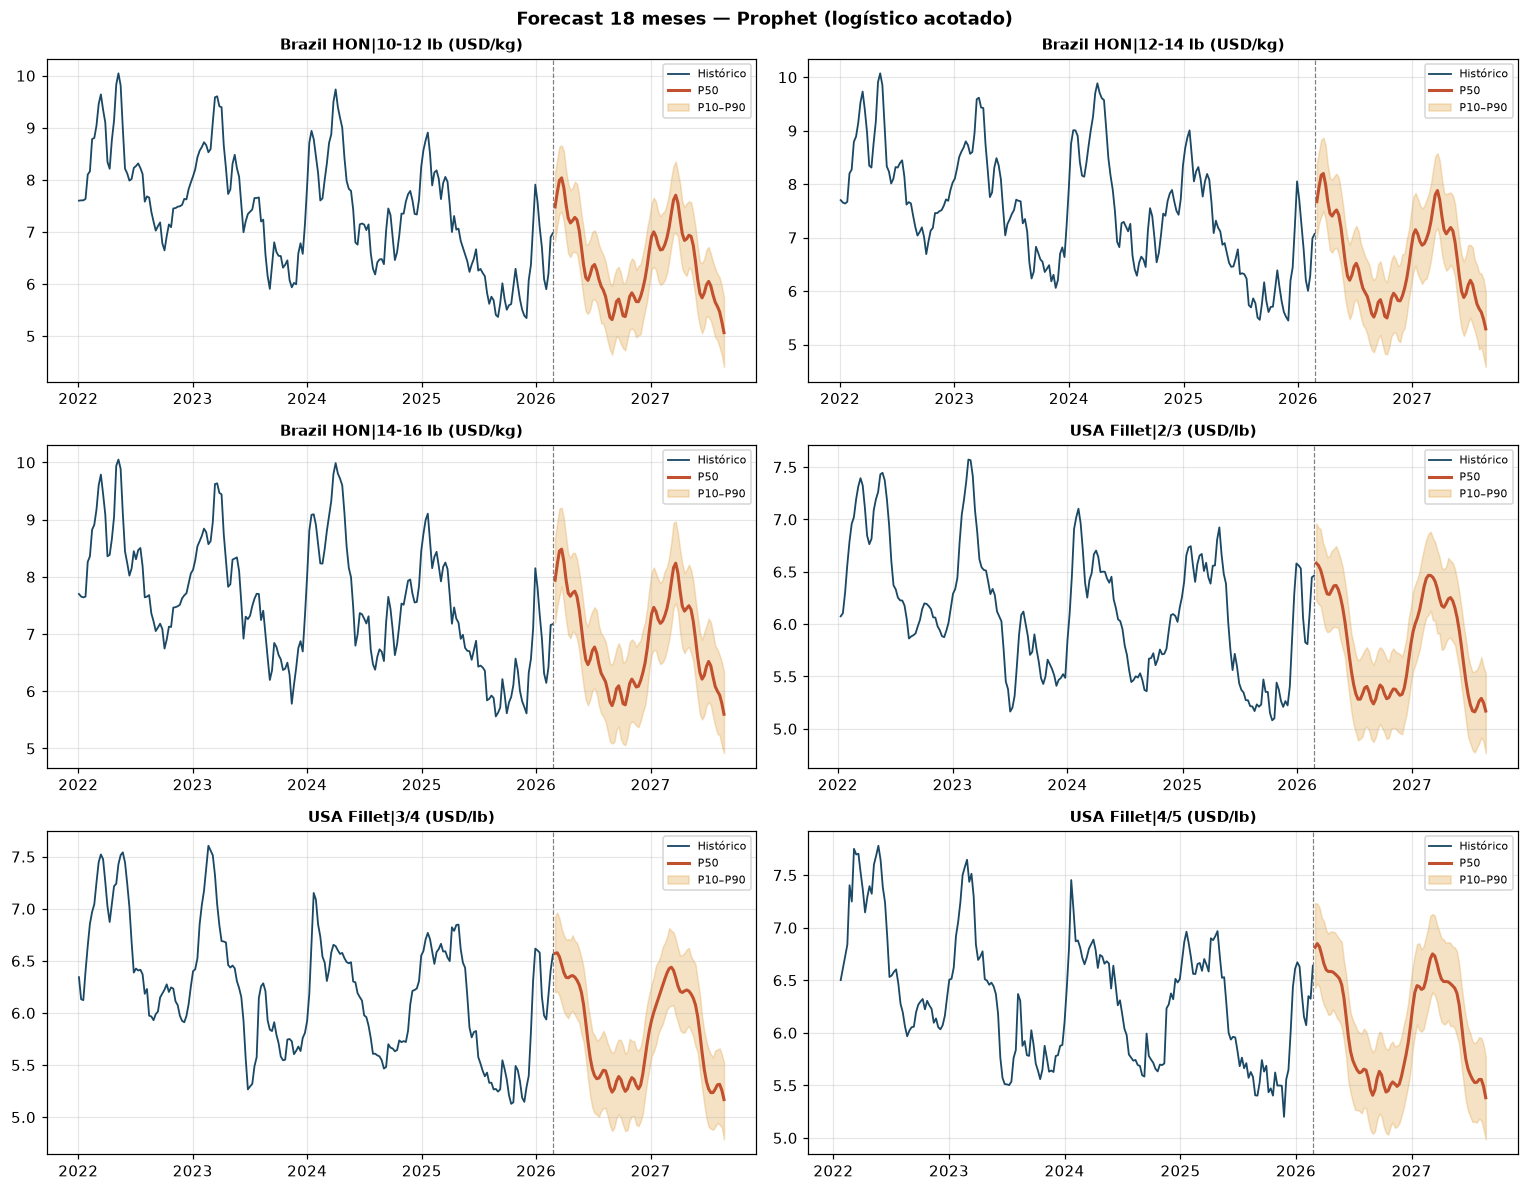

,serie,actual,P50_6m,P50_18m,var_18m_%
0,Brazil HON|10-12 lb,6.98,5.36,5.07,-27.4
1,Brazil HON|12-14 lb,7.07,5.58,5.29,-25.1
2,Brazil HON|14-16 lb,7.17,5.82,5.60,-22.0
3,USA Fillet|2/3,6.46,5.27,5.17,-20.0
4,USA Fillet|3/4,6.56,5.29,5.17,-21.2
5,USA Fillet|4/5,6.64,5.46,5.38,-18.9


In [8]:
def forecast_prophet_band(s, horizon=H, interval=0.80):
    m = _fit_prophet(s, interval)
    fut = m.make_future_dataframe(periods=horizon, freq='W-MON')
    fut['floor'] = m._floor; fut['cap'] = m._cap
    fc = m.predict(fut).iloc[-horizon:]
    return fc[['ds','yhat_lower','yhat','yhat_upper']]

fig, axes = plt.subplots(3, 2, figsize=(14, 11))
resumen = []
for ax, col in zip(axes.ravel(), SERIES):
    s = serie(col); unidad = 'USD/kg' if col.startswith('Brazil') else 'USD/lb'
    fc = forecast_prophet_band(s)
    ax.plot(s.index, s.values, color='#1b4965', lw=1.2, label='Histórico')
    ax.plot(fc['ds'], fc['yhat'], color='#c1502e', lw=2, label='P50')
    ax.fill_between(fc['ds'], fc['yhat_lower'], fc['yhat_upper'],
                    color='#e09f3e', alpha=.3, label='P10–P90')
    ax.axvline(s.index[-1], color='gray', ls='--', lw=.8)
    ax.set_title(f'{col} ({unidad})', fontweight='bold', fontsize=10); ax.legend(fontsize=7)
    resumen.append({'serie': col, 'actual': round(s.iloc[-1],2),
                    'P50_6m': round(fc['yhat'].iloc[25],2),
                    'P50_18m': round(fc['yhat'].iloc[-1],2),
                    'var_18m_%': round((fc['yhat'].iloc[-1]/s.iloc[-1]-1)*100,1)})
fig.suptitle('Forecast 18 meses — Prophet (logístico acotado)', fontweight='bold')
fig.tight_layout(); plt.show()
pd.DataFrame(resumen)